In [ ]:
!pip install wandb

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import wandb
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc

In [17]:
wandb.login() 

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

  ········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\Usuario\_netrc
wandb: Currently logged in as: andre-brandao-067 (andre-brandao-067-ufrn) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [18]:
# Global variables
val_size = 0.20
seed = 42
project_name = "depression-prediction"
output_dir = "output"

In [22]:
# Dataset
class DepressionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y.values)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [23]:
# Modelo classificação de depressão
class DepressionModel(nn.Module):
    def __init__(self, input_size, hidden_size=128):
        super(DepressionModel, self).__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.act1 = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.layer2 = nn.Linear(hidden_size, 2)  # Binário: depressão ou não
        
    def forward(self, x):
        x = self.layer1(x)
        x = self.act1(x)
        x = self.dropout(x)
        x = self.layer2(x)
        return x

In [24]:
# Iniciar wandb
run = wandb.init(
    project=project_name,
    config={
        "val_size": val_size,
        "seed": seed,
        "batch_size": 32,
        "epochs": 50,
        "learning_rate": 0.001
    }
)

In [25]:
# Criar diretório de output
os.makedirs(output_dir, exist_ok=True)

In [26]:
# 1. Carregamento de dados
print("\n" + "="*50)
print("1. CARREGAMENTO DE DADOS")
print("="*50)


1. CARREGAMENTO DE DADOS


In [33]:
# Caminho do dataset
data_path = "datasets/train.csv"
target_col = "Depression"

In [34]:
# Carregar dados
df = pd.read_csv(data_path)
print(f"Shape do dataset: {df.shape}")
print(f"\nPrimeiras linhas do dataset:")
print(df.head())

Shape do dataset: (140700, 20)

Primeiras linhas do dataset:
   id      Name  Gender   Age           City Working Professional or Student  \
0   0  Aaradhya  Female  49.0       Ludhiana            Working Professional   
1   1     Vivan    Male  26.0       Varanasi            Working Professional   
2   2    Yuvraj    Male  33.0  Visakhapatnam                         Student   
3   3    Yuvraj    Male  22.0         Mumbai            Working Professional   
4   4      Rhea  Female  30.0         Kanpur            Working Professional   

         Profession  Academic Pressure  Work Pressure  CGPA  \
0              Chef                NaN            5.0   NaN   
1           Teacher                NaN            4.0   NaN   
2               NaN                5.0            NaN  8.97   
3           Teacher                NaN            5.0   NaN   
4  Business Analyst                NaN            1.0   NaN   

   Study Satisfaction  Job Satisfaction     Sleep Duration Dietary Habits  \
0 

In [35]:
# Informações do dataset
print("\nInformações do dataset:")
print(df.info())


Informações do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140700 entries, 0 to 140699
Data columns (total 20 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   id                                     140700 non-null  int64  
 1   Name                                   140700 non-null  object 
 2   Gender                                 140700 non-null  object 
 3   Age                                    140700 non-null  float64
 4   City                                   140700 non-null  object 
 5   Working Professional or Student        140700 non-null  object 
 6   Profession                             104070 non-null  object 
 7   Academic Pressure                      27897 non-null   float64
 8   Work Pressure                          112782 non-null  float64
 9   CGPA                                   27898 non-null   float64
 10  Study Satisfaction             

In [36]:
# Estatísticas descritivas
print("\nEstatísticas descritivas:")
print(df.describe())


Estatísticas descritivas:
                  id            Age  Academic Pressure  Work Pressure  \
count  140700.000000  140700.000000       27897.000000  112782.000000   
mean    70349.500000      40.388621           3.142273       2.998998   
std     40616.735775      12.384099           1.380457       1.405771   
min         0.000000      18.000000           1.000000       1.000000   
25%     35174.750000      29.000000           2.000000       2.000000   
50%     70349.500000      42.000000           3.000000       3.000000   
75%    105524.250000      51.000000           4.000000       4.000000   
max    140699.000000      60.000000           5.000000       5.000000   

               CGPA  Study Satisfaction  Job Satisfaction  Work/Study Hours  \
count  27898.000000        27897.000000     112790.000000     140700.000000   
mean       7.658636            2.944940          2.974404          6.252679   
std        1.464466            1.360197          1.416078          3.853615   

In [37]:
# 2. Visualização inicial
print("\n" + "="*50)
print("2. VISUALIZAÇÃO INICIAL")
print("="*50)


2. VISUALIZAÇÃO INICIAL


In [38]:
# Verificar distribuição da variável alvo
print("\nDistribuição da variável alvo:")
target_counts = df[target_col].value_counts()
print(target_counts)


Distribuição da variável alvo:
Depression
0    115133
1     25567
Name: count, dtype: int64


In [45]:
# Converter Depression para tipo numérico
df["Depression"] = df["Depression"].astype(int)

2025-05-16 20:39:38,947 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-16 20:39:39,016 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


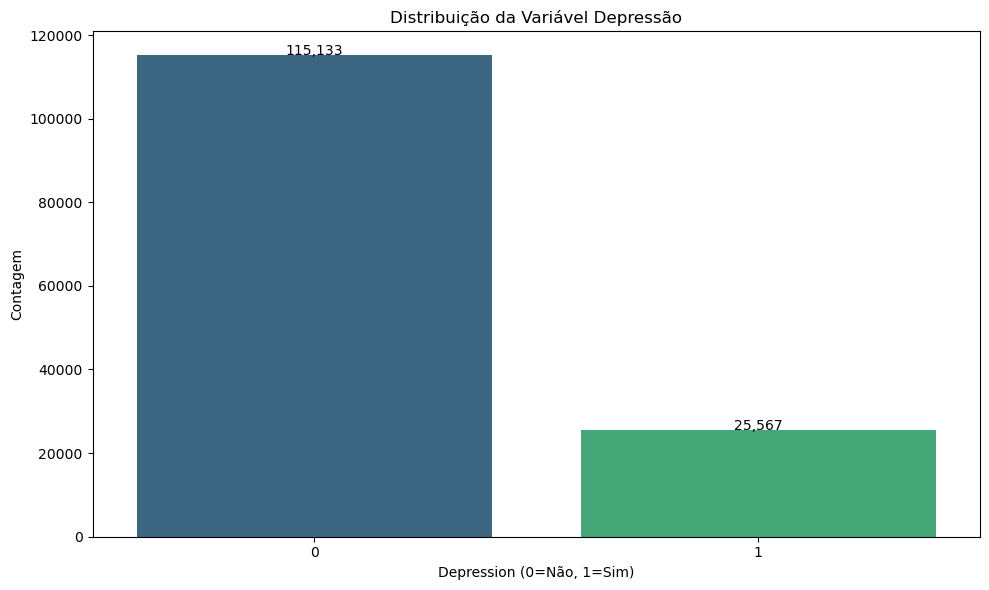

In [46]:
plt.figure(figsize=(10, 6))
# Correção do warning sobre palette/hue
ax = sns.countplot(x="Depression", data=df, hue="Depression", palette="viridis", legend=False)
plt.title("Distribuição da Variável Depressão")
plt.xlabel("Depression (0=Não, 1=Sim)")
plt.ylabel("Contagem")

# Adicionar valores em cada barra
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 0.5,
            '{:,}'.format(int(height)), ha="center")

plt.tight_layout()
plt.show()

In [49]:
# Separar features e target
X = df.drop(columns=[target_col])
y = df[target_col]
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=val_size, random_state=seed, stratify=y
)


X shape: (140700, 19)
y shape: (140700,)


In [50]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# 4. Feature Engineering
print("\n" + "="*50)
print("4. FEATURE ENGINEERING")
print("="*50)

X_train shape: (112560, 19)
X_test shape: (28140, 19)

4. FEATURE ENGINEERING


In [54]:
# Modifique a inicialização do OneHotEncoder para incluir handle_unknown='ignore'
onehot = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# Seu código para identificar colunas categóricas permanece o mesmo
cat_columns = X_train.select_dtypes(include=['object']).columns.tolist()

if len(cat_columns) > 0:
    # Ajuste o encoder em todas as categorias possíveis (combinando treino e teste)
    onehot.fit(X_train[cat_columns])
    
    # Transformar dados
    encoded_train = onehot.transform(X_train[cat_columns])
    encoded_test = onehot.transform(X_test[cat_columns])
    
    # Obter nomes das novas colunas
    new_cols = []
    for i, col in enumerate(cat_columns):
        cats = onehot.categories_[i][1:]  # Drop first category
        for cat in cats:
            new_cols.append(f"{col}_{cat}")
    
    # Criar DataFrames
    encoded_df_train = pd.DataFrame(encoded_train, columns=new_cols, index=X_train.index)
    encoded_df_test = pd.DataFrame(encoded_test, columns=new_cols, index=X_test.index)
    
    # Remover colunas originais e concatenar
    X_train_num = X_train.drop(columns=cat_columns)
    X_test_num = X_test.drop(columns=cat_columns)
    
    X_train = pd.concat([X_train_num, encoded_df_train], axis=1)
    X_test = pd.concat([X_test_num, encoded_df_test], axis=1)

    print(f"\nShapes após One-Hot Encoding:")
    print(f"X_train: {X_train.shape}")
    print(f"X_test: {X_test.shape}")
else:
    print("\nNenhuma coluna categórica encontrada.")
    onehot = None



Nenhuma coluna categórica encontrada.


In [55]:
# Normalização
print("\nAplicando normalização com StandardScaler...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Aplicando normalização com StandardScaler...


In [56]:
# 5. Treinamento do modelo
print("\n" + "="*50)
print("5. TREINAMENTO DO MODELO")
print("="*50)


5. TREINAMENTO DO MODELO


In [57]:
# Hiperparâmetros
batch_size = 32
epochs = 50
learning_rate = 0.001
hidden_size = 128

# Datasets e DataLoaders
train_dataset = DepressionDataset(X_train_scaled, y_train)
test_dataset = DepressionDataset(X_test_scaled, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

print(f"Train dataset: {len(train_dataset)} amostras")
print(f"Test dataset: {len(test_dataset)} amostras")

Train dataset: 112560 amostras
Test dataset: 28140 amostras


In [58]:
# Dispositivo (GPU/CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Inicializar modelo
input_size = X_train_scaled.shape[1]
model = DepressionModel(input_size, hidden_size)
model.to(device)

print(f"Estrutura do modelo:\n{model}")

# Função de perda e otimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

Usando dispositivo: cpu
Estrutura do modelo:
DepressionModel(
  (layer1): Linear(in_features=693, out_features=128, bias=True)
  (act1): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (layer2): Linear(in_features=128, out_features=2, bias=True)
)


In [59]:
# Tracking training
wandb.watch(model, log="all")

In [60]:
# Listas para acompanhar progresso
train_losses = []
val_losses = []
accuracies = []

# Loop de treinamento
for epoch in range(epochs):
    # Treinamento
    model.train()
    running_loss = 0.0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass e otimização
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
    
    epoch_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_loss)
    
    # Validação
    model.eval()
    val_loss = 0.0
    predictions = []
    actual = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            
            predictions.extend(preds.cpu().numpy())
            actual.extend(labels.cpu().numpy())
    
    val_loss = val_loss / len(test_dataset)
    val_losses.append(val_loss)
    
    accuracy = accuracy_score(actual, predictions)
    accuracies.append(accuracy)
    
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": epoch_loss,
        "val_loss": val_loss,
        "accuracy": accuracy
    })
    
    print(f"Época {epoch+1}/{epochs}, "
          f"Treino Loss: {epoch_loss:.4f}, "
          f"Val Loss: {val_loss:.4f}, "
          f"Acurácia: {accuracy:.4f}")
    
    # Salvar plots a cada 10 épocas
    if (epoch + 1) % 10 == 0 or epoch == 0 or epoch == epochs - 1:
        plt.figure(figsize=(12, 5))
        
        plt.subplot(1, 2, 1)
        plt.plot(range(1, epoch + 2), train_losses, label='Treino')
        plt.plot(range(1, epoch + 2), val_losses, label='Validação')
        plt.xlabel('Época')
        plt.ylabel('Perda')
        plt.title('Evolução da Perda')
        plt.legend()
        
        plt.subplot(1, 2, 2)
        plt.plot(range(1, epoch + 2), accuracies, label='Acurácia')
        plt.xlabel('Época')
        plt.ylabel('Acurácia')
        plt.title('Evolução da Acurácia')
        plt.legend()
        
        plt.tight_layout()
        progress_path = os.path.join(output_dir, f'progress_epoch_{epoch+1}.png')
        plt.savefig(progress_path)
        plt.close()
        
        wandb.log({f"progress_epoch_{epoch+1}": wandb.Image(progress_path)})

Época 1/50, Treino Loss: 0.1831, Val Loss: 0.1641, Acurácia: 0.9362
Época 2/50, Treino Loss: 0.1629, Val Loss: 0.1654, Acurácia: 0.9354
Época 3/50, Treino Loss: 0.1595, Val Loss: 0.1706, Acurácia: 0.9347
Época 4/50, Treino Loss: 0.1613, Val Loss: 0.1750, Acurácia: 0.9355
Época 5/50, Treino Loss: 0.1582, Val Loss: 0.1951, Acurácia: 0.9364
Época 6/50, Treino Loss: 0.1570, Val Loss: 0.1878, Acurácia: 0.9376
Época 7/50, Treino Loss: 0.1621, Val Loss: 0.2015, Acurácia: 0.9364
Época 8/50, Treino Loss: 0.1595, Val Loss: 0.2014, Acurácia: 0.9351
Época 9/50, Treino Loss: 0.1615, Val Loss: 0.2397, Acurácia: 0.9345
Época 10/50, Treino Loss: 0.1688, Val Loss: 0.2469, Acurácia: 0.9332
Época 11/50, Treino Loss: 0.1513, Val Loss: 0.2477, Acurácia: 0.9321
Época 12/50, Treino Loss: 0.1530, Val Loss: 0.2704, Acurácia: 0.9341
Época 13/50, Treino Loss: 0.1518, Val Loss: 0.2949, Acurácia: 0.9329
Época 14/50, Treino Loss: 0.1667, Val Loss: 0.3135, Acurácia: 0.9327
Época 15/50, Treino Loss: 0.1524, Val Loss:

In [61]:
# 6. Avaliação do modelo
print("\n" + "="*50)
print("6. AVALIAÇÃO DO MODELO")
print("="*50)


6. AVALIAÇÃO DO MODELO


In [62]:
# Avaliação final
model.eval()
all_preds = []
all_labels = []
all_probs = []

In [63]:
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())  # Probabilidade da classe positiva

In [64]:
# Métricas de classificação
print("\nRelatório de classificação:")
report = classification_report(all_labels, all_preds)
print(report)


Relatório de classificação:
              precision    recall  f1-score   support

           0       0.95      0.96      0.96     23027
           1       0.82      0.79      0.80      5113

    accuracy                           0.93     28140
   macro avg       0.88      0.88      0.88     28140
weighted avg       0.93      0.93      0.93     28140



In [67]:
# Métricas específicas
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='binary')
recall = recall_score(all_labels, all_preds, average='binary')
f1 = f1_score(all_labels, all_preds, average='binary')

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Accuracy: 0.9298
Precision: 0.8155
Recall: 0.7929
F1 Score: 0.8040


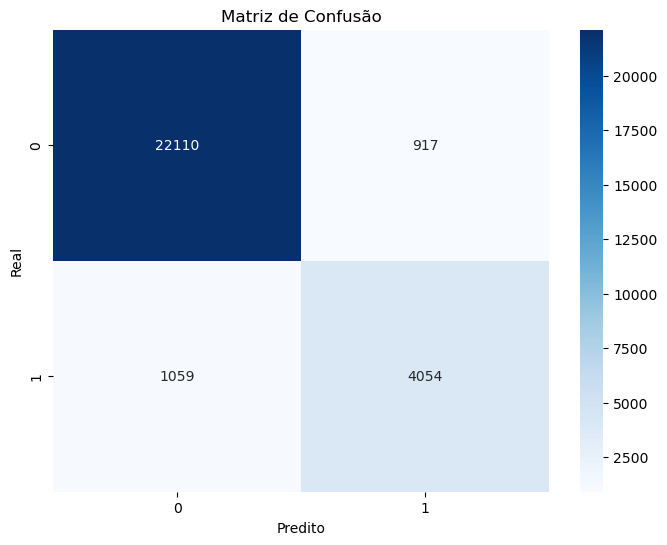

In [72]:
# Matriz de confusão
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão')
plt.ylabel('Real')
plt.xlabel('Predito')

cm_path = os.path.join(output_dir, 'confusion_matrix.png')
plt.savefig(cm_path)
wandb.log({"confusion_matrix": wandb.Image(cm_path)})


AUC-ROC: 0.9633


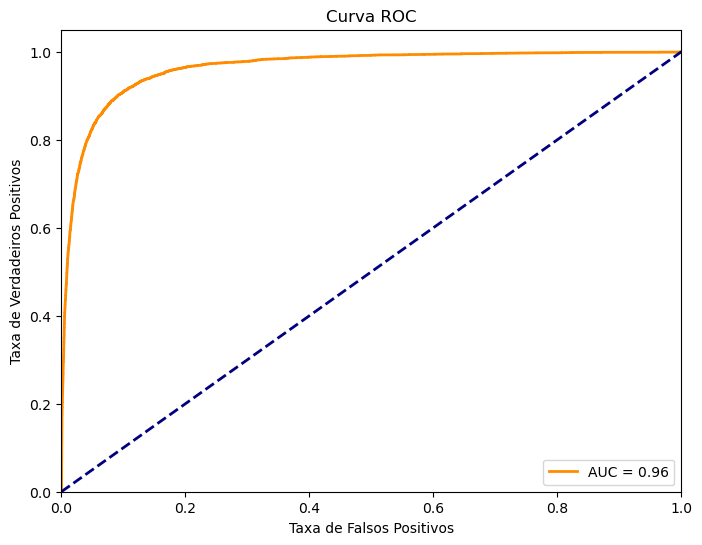

In [74]:
# Curva ROC
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

print(f"\nAUC-ROC: {roc_auc:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC')
plt.legend(loc="lower right")

roc_path = os.path.join(output_dir, 'roc_curve.png')
plt.savefig(roc_path)
wandb.log({"roc_curve": wandb.Image(roc_path), "roc_auc": roc_auc})

In [76]:
# 7. Log de métricas no wandb
wandb.log({
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "auc": roc_auc,
    "confusion_matrix": wandb.plot.confusion_matrix(
        probs=None,
        y_true=all_labels,
        preds=all_preds,
        class_names=["Não", "Sim"]
    ),
    "classification_report": wandb.Table(
        dataframe=pd.DataFrame(classification_report(all_labels, all_preds, output_dict=True)).transpose()
    )
})

In [77]:
# 8. Salvar modelo e artefatos
print("\n" + "="*50)
print("8. SALVANDO MODELO E ARTEFATOS")
print("="*50)


8. SALVANDO MODELO E ARTEFATOS


In [78]:
# Salvar modelo PyTorch
model_path = os.path.join(output_dir, 'model.pt')
torch.save(model.state_dict(), model_path)
print(f"Modelo salvo em {model_path}")

# Salvar scaler
scaler_path = os.path.join(output_dir, 'scaler.joblib')
joblib.dump(scaler, scaler_path)
print(f"Scaler salvo em {scaler_path}")

Modelo salvo em output\model.pt
Scaler salvo em output\scaler.joblib


In [81]:
# Salvar encoder se existir
if onehot is not None:
    encoder_path = os.path.join(output_dir, 'onehot_encoder.joblib')
    joblib.dump(onehot, encoder_path)
    print(f"Encoder salvo em {encoder_path}")

In [80]:
# Salvar feature names
feature_names = X_train.columns.tolist()
feature_path = os.path.join(output_dir, 'feature_names.csv')
pd.DataFrame({'feature_name': feature_names}).to_csv(feature_path, index=False)
print(f"Nomes das features salvos em {feature_path}")

Nomes das features salvos em output\feature_names.csv


In [82]:
# Log de artefatos no wandb
wandb.save(model_path)
wandb.save(scaler_path)
if onehot is not None:
    wandb.save(encoder_path)
wandb.save(feature_path)

['C:\\Users\\Usuario\\Documents\\Mestrado\\ML\\DepressionRiskPredictor\\wandb\\run-20250516_202713-4zlpksjx\\files\\output\\feature_names.csv']

In [83]:
# Salvar hiperparâmetros
config_path = os.path.join(output_dir, 'config.json')
import json
with open(config_path, 'w') as f:
    json.dump({
        "input_size": input_size,
        "hidden_size": hidden_size,
        "batch_size": batch_size,
        "learning_rate": learning_rate,
        "epochs": epochs
    }, f)
print(f"Configuração salva em {config_path}")
wandb.save(config_path)

Configuração salva em output\config.json


['C:\\Users\\Usuario\\Documents\\Mestrado\\ML\\DepressionRiskPredictor\\wandb\\run-20250516_202713-4zlpksjx\\files\\output\\config.json']

In [84]:
print("\n" + "="*50)
print("TREINAMENTO FINALIZADO COM SUCESSO!")
print("="*50)


TREINAMENTO FINALIZADO COM SUCESSO!


In [85]:
# Finalizar wandb
wandb.finish()

accuracy,█▇▇▇██▇▇▆▅▅▅▅▄▄▅▄▄▄▄▄▃▃▃▃▄▄▂▃▃▃▃▃▂▃▂▃▁▃▃
auc,▁
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
f1,▁
precision,▁
recall,▁
roc_auc,▁▁
train_loss,▅▃▃▂▂▃▄▂▂▂▂▂▄▂▂▃▂▄▁▁▂▃▂▂▂▄▃▆▃▁▃▅▂▁▄▁▆█▃█
val_loss,▁▁▁▁▁▁▂▂▂▂▂▃▂▃▃▄▄▄▄▄▄▅▅▅▅▆▅▅▆▆▇▆▇▇▇█▇█▇█
accuracy,0.92978
auc,0.96333
